# 🔷 Session 1 & 2 — Introduction to OpenVINO

**Intel DevMeet 1.0 Nagpur — Text to Image Generation with Qwen using OpenVINO**

---

This notebook covers the foundational concepts of the **Intel OpenVINO Toolkit** and walks through a basic tutorial on model optimization and inference.

> 📌 This notebook is intended to run on **Google Colab**.

## 📑 Table of Contents

1. [What is Intel OpenVINO?](#what-is-openvino)
2. [AI Inference Acceleration & Optimization](#inference-acceleration)
3. [Supported Frameworks & Deployment Pipeline](#supported-frameworks)
4. [Install Dependencies](#install-dependencies)
5. [Model Optimization Workflow](#model-optimization)
6. [Converting a Model to OpenVINO IR](#converting-model)
7. [Running Inference with OpenVINO Runtime](#running-inference)
8. [Summary](#summary)

## 1. What is Intel OpenVINO? <a id='what-is-openvino'></a>

[Intel OpenVINO™](https://www.intel.com/content/www/us/en/developer/tools/openvino-toolkit/overview.html) (Open Visual Inference & Neural Network Optimization) is an open-source toolkit for optimizing and deploying AI inference on Intel hardware (CPUs, GPUs, VPUs, and FPGAs) as well as heterogeneous execution environments.

### Key Features
- ⚡ **High-performance inference** on Intel CPUs, integrated GPUs, and neural compute sticks.
- 🔄 **Framework agnostic** — supports models from PyTorch, TensorFlow, ONNX, PaddlePaddle, and more.
- 🛠️ **Model Optimizer** — converts and optimizes trained models into OpenVINO's Intermediate Representation (IR).
- 📦 **Compact deployment** — reduced model size and memory footprint for edge devices.
- 🌐 **Cross-platform** — runs on Linux, Windows, and macOS.

## 2. AI Inference Acceleration & Optimization <a id='inference-acceleration'></a>

OpenVINO accelerates inference through several mechanisms:

| Technique | Description |
|---|---|
| **INT8 Quantization** | Reduces model weights from FP32 to INT8, drastically cutting memory and compute. |
| **Layer Fusion** | Combines consecutive operations (e.g., Conv + BN + ReLU) into a single kernel. |
| **Graph Pruning** | Removes unused nodes from the computation graph. |
| **Hardware-aware Scheduling** | Dispatches compute to the optimal device (CPU, iGPU, etc.). |
| **Asynchronous Inference** | Overlaps pre/post-processing with inference for higher throughput. |

## 3. Supported Frameworks & Deployment Pipeline <a id='supported-frameworks'></a>

```
Trained Model (PyTorch / TensorFlow / ONNX / PaddlePaddle)
        │
        ▼
  [ OpenVINO Model Optimizer / OVC ]
        │
        ▼
  OpenVINO IR (.xml + .bin)
        │
        ▼
  [ OpenVINO Runtime (Core, CompiledModel) ]
        │
        ▼
  Inference on Target Hardware
  (CPU / Intel GPU / Neural Compute Stick / FPGA)
```

## 4. Install Dependencies <a id='install-dependencies'></a>

Run the cell below to install the required packages.

In [ ]:
!pip uninstall -y numpy torch torchvision torchaudio
!pip install numpy==1.26.4
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: torch 2.11.0+cpu
Uninstalling torch-2.11.0+cpu:
  Successfully uninstalled torch-2.11.0+cpu
Found existing installation: torchvision 0.26.0+cpu
Uninstalling torchvision-0.26.0+cpu:
  Successfully uninstalled torchvision-0.26.0+cpu
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires torch>=1.11.0, which is not installed.
peft 0.18.1 requires torch>=1.13.0, which is 

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.11.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.26.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchaudio-2.11.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.11.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl (190.3 MB)
Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.26.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl (1.9 MB)
Using cached https://download-r2.pytorch.org/whl/cpu/torchaudio-2.11.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl (341 kB)
^C


In [ ]:
# Install OpenVINO and supporting libraries
%pip install -q openvino openvino-dev[pytorch,onnx] torch torchvision pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/5

In [ ]:
import openvino as ov
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print(f"OpenVINO version: {ov.__version__}")
print(f"PyTorch version:  {torch.__version__}")

OpenVINO version: 2024.6.0-17404-4c0f47d2335-releases/2024/6
PyTorch version:  2.11.0+cu130


## 5. Model Optimization Workflow <a id='model-optimization'></a>

The OpenVINO optimization workflow involves three key steps:

1. **Export** the trained model from the source framework (e.g., PyTorch → ONNX).
2. **Convert** the model to OpenVINO IR format using `ov.convert_model()` or the `ovc` CLI tool.
3. **Compile** the IR model for the target hardware and run inference.

Let's walk through this using a simple ResNet-18 model as an example.

In [ ]:
import torchvision.models as models

# Load a pretrained ResNet-18 model from PyTorch
pytorch_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
pytorch_model.eval()
print("ResNet-18 loaded successfully.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]


ResNet-18 loaded successfully.


## 6. Converting a Model to OpenVINO IR <a id='converting-model'></a>

Use `ov.convert_model()` to convert the PyTorch model directly — no intermediate ONNX export needed.

In [ ]:
# Define a representative input shape: batch=1, channels=3, height=224, width=224
dummy_input = torch.zeros(1, 3, 224, 224)

# Convert the PyTorch model to OpenVINO IR
ov_model = ov.convert_model(pytorch_model, example_input=dummy_input)
print("Model converted to OpenVINO IR.")

# (Optional) Save the IR model to disk
ov.save_model(ov_model, "resnet18.xml")
print("IR model saved as resnet18.xml + resnet18.bin")

Model converted to OpenVINO IR.
IR model saved as resnet18.xml + resnet18.bin
Model converted to OpenVINO IR.Model converted to OpenVINO IR.

## 7. Running Inference with OpenVINO Runtime <a id='running-inference'></a>

We use the OpenVINO `Core` class to compile and run the model on the available device.

In [ ]:
# List available inference devices
core = ov.Core()
print("Available devices:", core.available_devices)

Available devices: ['CPU']


In [ ]:
# Compile the model for CPU inference
compiled_model = core.compile_model(ov_model, device_name="CPU")

# Create a random input tensor (simulating an image batch)
input_data = np.random.rand(1, 3, 224, 224).astype(np.float32)

# Run inference
output = compiled_model([input_data])
logits = output[0]  # shape: (1, 1000) for ImageNet classes

predicted_class = np.argmax(logits[0])
print(f"Predicted ImageNet class index: {predicted_class}")

Predicted ImageNet class index: 111


### ⏱️ Benchmark: Measuring Inference Latency

In [ ]:
import time

N_RUNS = 100
start = time.perf_counter()
for _ in range(N_RUNS):
    compiled_model([input_data])
elapsed = time.perf_counter() - start

print(f"Average inference latency over {N_RUNS} runs: {elapsed / N_RUNS * 1000:.2f} ms")

Average inference latency over 100 runs: 65.11 ms


🧠 OpenVINO Inference with Image Input (ResNet-18)
📌 Objective

Perform image classification using a PyTorch ResNet-18 model converted to OpenVINO IR and run inference on a real image.

In [ ]:
from google.colab import files

uploaded = files.upload()
image_path = next(iter(uploaded.keys()))

print("Uploaded image:", image_path)

Saving images (1).jpg to images (1).jpg
Uploaded image: images (1).jpg


Original image size: (289, 175)


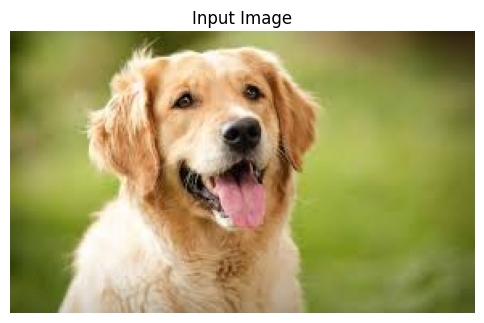

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

print("Original image size:", image.size)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [ ]:
import numpy as np

# ImageNet normalization values
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_image(pil_img, size=224):
    img = pil_img.resize((size, size))
    img = np.array(img).astype(np.float32) / 255.0
    img = (img - mean) / std
    img = np.transpose(img, (2, 0, 1))   # HWC → CHW
    img = np.expand_dims(img, axis=0)    # CHW → NCHW
    return img

input_data = preprocess_image(image)
print("Input shape:", input_data.shape)

Input shape: (1, 3, 224, 224)


In [ ]:
output = compiled_model([input_data])
logits = output[0]   # Shape: (1, 1000)

import numpy as np
predicted_class = int(np.argmax(logits[0]))

print("Predicted class index:", predicted_class)

Predicted class index: 207


In [ ]:
import torch
import torchvision.models as models

# Load ImageNet labels
weights = models.ResNet18_Weights.DEFAULT
categories = weights.meta["categories"]

# Convert logits → probabilities
probs = torch.nn.functional.softmax(torch.tensor(logits[0]), dim=0).numpy()

# Get top-5 predictions
top5_idx = np.argsort(probs)[-5:][::-1]

print("Top-5 Predictions:")
for i, idx in enumerate(top5_idx, 1):
    print(f"{i}. {categories[idx]} : {probs[idx]*100:.2f}%")

Top-5 Predictions:
1. golden retriever : 92.43%
2. cocker spaniel : 1.18%
3. otterhound : 1.05%
4. Labrador retriever : 0.89%
5. clumber : 0.69%


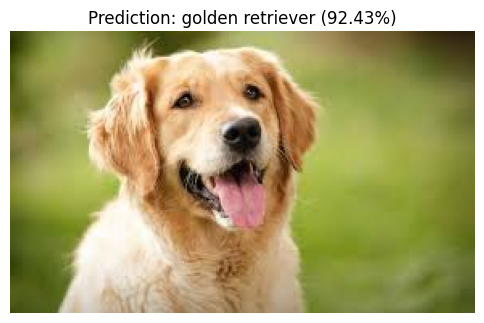

In [ ]:
top1_label = categories[top5_idx[0]]
top1_conf = probs[top5_idx[0]] * 100

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {top1_label} ({top1_conf:.2f}%)")
plt.show()

## 8. Summary <a id='summary'></a>

In this notebook you learned:

- ✅ What Intel OpenVINO is and why it matters for AI deployment.
- ✅ The key acceleration techniques OpenVINO applies (quantization, fusion, pruning).
- ✅ Which frameworks are supported and the general deployment pipeline.
- ✅ How to convert a PyTorch model to OpenVINO IR format.
- ✅ How to compile an OpenVINO IR model and run inference on the CPU.

---

➡️ **Next:** Open `02_Text_to_Image_Generation_with_Qwen_OpenVINO.ipynb` for the hands-on Text-to-Image workshop.